In [17]:
pip install scikeras


Note: you may need to restart the kernel to use updated packages.


Loading data...

Training optimized model...
Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - calving_accuracy: 0.5986 - calving_loss: 0.6840 - lameness_accuracy: 0.5842 - lameness_loss: 0.6778 - loss: 2.7104 - mastitis_accuracy: 0.5613 - mastitis_loss: 0.6728 - oestrus_accuracy: 0.5808 - oestrus_loss: 0.6757 - val_calving_accuracy: 0.8330 - val_calving_loss: 0.6233 - val_lameness_accuracy: 0.8951 - val_lameness_loss: 0.6114 - val_loss: 2.4958 - val_mastitis_accuracy: 0.8607 - val_mastitis_loss: 0.6135 - val_oestrus_accuracy: 0.6901 - val_oestrus_loss: 0.6477
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - calving_accuracy: 0.8434 - calving_loss: 0.5984 - lameness_accuracy: 0.9007 - lameness_loss: 0.5807 - loss: 2.3933 - mastitis_accuracy: 0.9047 - mastitis_loss: 0.5815 - oestrus_accuracy: 0.7201 - oestrus_loss: 0.6326 - val_calving_accuracy: 0.8651 - val_calving_loss: 0.5161 - val_lameness_accuracy: 0.8990 - val_lameness_loss: 0.4781 - val_loss: 2.0484 - val_mastitis_accuracy:

OESTRUS AUC: 0.7259
CALVING AUC: 0.8149
LAMENESS AUC: 0.6368
MASTITIS AUC: 0.5775

Model saved successfully!


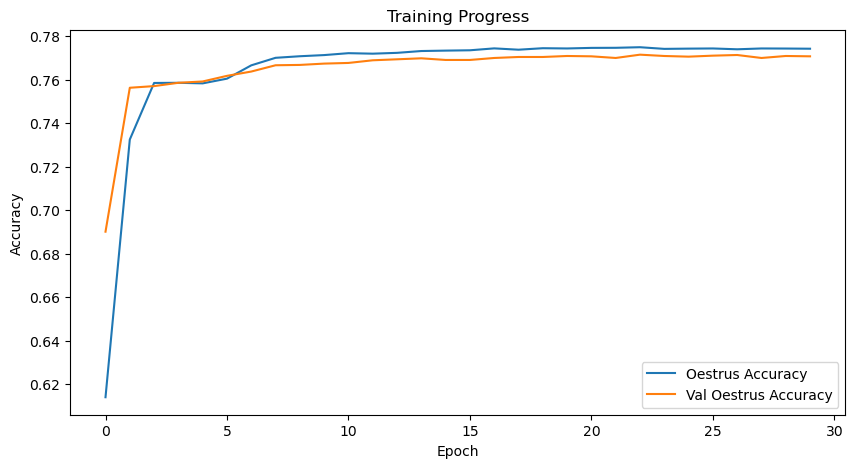

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from keras.models import Model
from keras.layers import Input, LSTM, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)

# 1. Load and prepare data
print("Loading data...")
data = pd.read_csv('balanced_datasets/multi_output_balanced.csv', 
                  usecols=lambda x: x not in ['Unnamed: 0', 'Unnamed: 1', 'disturbance', 'cow', 'date', 'any_disease'])

# Separate features and targets
features = data.drop(columns=['oestrus', 'calving', 'lameness', 'mastitis'])
targets = data[['oestrus', 'calving', 'lameness', 'mastitis']].values

# 2. Preprocessing
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
reshaped_data = scaled_features.reshape(scaled_features.shape[0], 1, scaled_features.shape[1])

# 3. Simplified multi-output model (single training pass)
def create_final_model():
    inputs = Input(shape=(1, reshaped_data.shape[2]))
    
    # Single LSTM layer for speed
    x = LSTM(32)(inputs)
    
    # Four output branches
    oestrus = Dense(1, activation='sigmoid', name='oestrus')(x)
    calving = Dense(1, activation='sigmoid', name='calving')(x)
    lameness = Dense(1, activation='sigmoid', name='lameness')(x)
    mastitis = Dense(1, activation='sigmoid', name='mastitis')(x)
    
    model = Model(inputs=inputs, outputs=[oestrus, calving, lameness, mastitis])
    
    # Metrics for each output
    metrics = {
        'oestrus': ['accuracy'],
        'calving': ['accuracy'], 
        'lameness': ['accuracy'],
        'mastitis': ['accuracy']
    }
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=metrics
    )
    return model

# 4. Train final model directly (skip hyperparameter tuning for speed)
print("\nTraining optimized model...")
model = create_final_model()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    reshaped_data, targets,
    test_size=0.2,
    random_state=42,
    stratify=targets[:, 0]
)

# Train with early stopping
history = model.fit(
    X_train,
    [y_train[:, 0], y_train[:, 1], y_train[:, 2], y_train[:, 3]],
    validation_data=(X_test, [y_test[:, 0], y_test[:, 1], y_test[:, 2], y_test[:, 3]]),
    epochs=30,
    batch_size=512,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

# 5. Quick evaluation
print("\nEvaluating model...")
test_preds = model.predict(X_test)

for i, disease in enumerate(['oestrus', 'calving', 'lameness', 'mastitis']):
    auc = roc_auc_score(y_test[:, i], test_preds[i])
    print(f"{disease.upper()} AUC: {auc:.4f}")

# 6. Save model
model.save('fast_livestock_model.h5')
print("\nModel saved successfully!")

# 7. Simple plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['oestrus_accuracy'], label='Oestrus Accuracy')
plt.plot(history.history['val_oestrus_accuracy'], label='Val Oestrus Accuracy')
plt.title('Training Progress')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Loading data...

Starting hyperparameter tuning...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters: {'dropout_rate': 0.3, 'learning_rate': 0.0005, 'lstm_units': 32}

Running cross-validation...


C:\Users\vishn\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: calving_accuracy,calving_loss,lameness_accuracy,lameness_loss,loss,mastitis_accuracy,mastitis_loss,oestrus_accuracy,oestrus_loss
  current = self.get_monitor_value(logs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold AUCs: {'oestrus': 0.7406957334865216, 'calving': 0.8056220304363252, 'lameness': 0.6374194684155476, 'mastitis': 0.5955874659970705}


C:\Users\vishn\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: calving_accuracy,calving_loss,lameness_accuracy,lameness_loss,loss,mastitis_accuracy,mastitis_loss,oestrus_accuracy,oestrus_loss
  current = self.get_monitor_value(logs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold AUCs: {'oestrus': 0.720329066223401, 'calving': 0.8151260816549463, 'lameness': 0.6222477601963445, 'mastitis': 0.5980460220754648}


...

C:\Users\vishn\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: calving_accuracy,calving_loss,lameness_accuracy,lameness_loss,loss,mastitis_accuracy,mastitis_loss,oestrus_accuracy,oestrus_loss
  current = self.get_monitor_value(logs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold AUCs: {'oestrus': 0.73445278608167, 'calving': 0.8166861125045066, 'lameness': 0.6268178549638281, 'mastitis': 0.5700314474026775}


C:\Users\vishn\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: calving_accuracy,calving_loss,lameness_accuracy,lameness_loss,loss,mastitis_accuracy,mastitis_loss,oestrus_accuracy,oestrus_loss
  current = self.get_monitor_value(logs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fold AUCs: {'oestrus': 0.7322201924205731, 'calving': 0.8290381528462923, 'lameness': 0.6130756722304541, 'mastitis': 0.627684363334418}

Mean CV AUC scores:
oestrus: 0.7331
calving: 0.8167
lameness: 0.6256
mastitis: 0.5912

Training final model...
Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - calving_accuracy: 0.5843 - calving_loss: 0.6824 - lameness_accuracy: 0.6134 - lameness_loss: 0.6797 - loss: 2.7131 - mastitis_accuracy: 0.6164 - mastitis_loss: 0.6729 - oestrus_accuracy: 0.6182 - oestrus_loss: 0.6780 - val_calving_accuracy: 0.7800 - val_calving_loss: 0.6391 - val_lameness_accuracy: 0.7803 - val_lameness_loss: 0.6505 - val_loss: 2.6186 - val_mastitis_accuracy: 0.7854 - val_mastitis_loss: 0.6368 - val_oestrus_accuracy: 0.4991 - val_oestrus_loss: 0.6931
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - calving_accuracy: 0.7608 - calving_loss: 0.6058 - lameness_accuracy: 0.8919 - lameness_loss: 0.5893 - loss: 2.3589 - mastitis_accu

OESTRUS AUC: 0.6390
CALVING AUC: 0.7169
LAMENESS AUC: 0.4843
MASTITIS AUC: 0.4158

Model saved successfully!


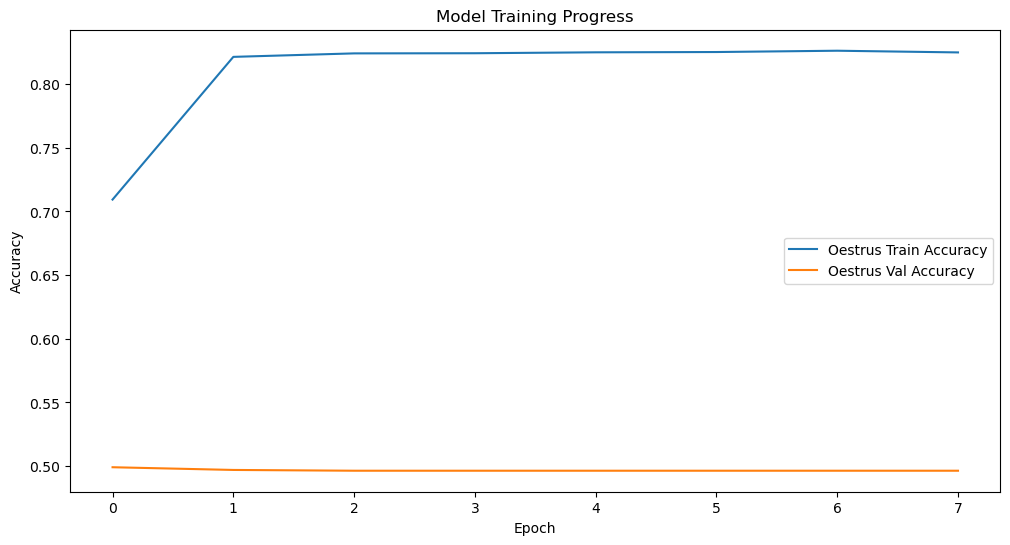

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
import matplotlib.pyplot as plt

# Set random seeds
np.random.seed(42)

# 1. Load and prepare data
print("Loading data...")
data = pd.read_csv('balanced_datasets/multi_output_balanced.csv')
data = data.drop(columns=['Unnamed: 0', 'Unnamed: 1', 'disturbance', 'cow', 'date', 'any_disease'])

# Separate features and targets
features = data.drop(columns=['oestrus', 'calving', 'lameness', 'mastitis'])
targets = data[['oestrus', 'calving', 'lameness', 'mastitis']].values

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(features)
X = X.reshape(X.shape[0], 1, X.shape[1])  # Reshape for LSTM

# 2. Define model building function for tuning (single output)
def build_tuning_model(lstm_units=32, dropout_rate=0.2, learning_rate=0.001):
    inputs = Input(shape=(1, X.shape[2]))
    
    x = LSTM(lstm_units)(inputs)
    x = Dropout(dropout_rate)(x)
    
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# 3. Hyperparameter tuning (using first target for speed)
print("\nStarting hyperparameter tuning...")

model = KerasClassifier(
    model=build_tuning_model,
    epochs=30,
    batch_size=256,
    verbose=0
)

param_grid = {
    'model__lstm_units': [32, 64],
    'model__dropout_rate': [0.2, 0.3],
    'model__learning_rate': [0.001, 0.0005],
    'batch_size': [128, 256]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1  # Use all cores
)

grid.fit(X, targets[:, 0])  # Tune on oestrus
best_params = {k.replace('model__', ''): v for k, v in grid.best_params_.items() 
              if k.startswith('model__')}
print("\nBest parameters:", best_params)

# 4. Final multi-output model with proper metrics
def build_final_model(lstm_units=32, dropout_rate=0.2, learning_rate=0.001):
    inputs = Input(shape=(1, X.shape[2]))
    
    x = LSTM(lstm_units)(inputs)
    x = Dropout(dropout_rate)(x)
    
    outputs = [
        Dense(1, activation='sigmoid', name='oestrus')(x),
        Dense(1, activation='sigmoid', name='calving')(x),
        Dense(1, activation='sigmoid', name='lameness')(x),
        Dense(1, activation='sigmoid', name='mastitis')(x)
    ]
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # Define metrics for each output
    metrics = {
        'oestrus': ['accuracy'],
        'calving': ['accuracy'],
        'lameness': ['accuracy'],
        'mastitis': ['accuracy']
    }
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=metrics
    )
    return model

# 5. Cross-validation
print("\nRunning cross-validation...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = targets[train_idx], targets[val_idx]
    
    model = build_final_model(**best_params)
    model.fit(
        X_train,
        {'oestrus': y_train[:, 0], 'calving': y_train[:, 1], 
         'lameness': y_train[:, 2], 'mastitis': y_train[:, 3]},
        epochs=50,
        batch_size=256,
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )
    
    val_preds = model.predict(X_val)
    fold_scores = [roc_auc_score(y_val[:, i], val_preds[i]) for i in range(4)]
    cv_scores.append(fold_scores)
    print(f"Fold AUCs: {dict(zip(['oestrus', 'calving', 'lameness', 'mastitis'], fold_scores))}")

# Calculate mean CV performance
mean_cv_auc = np.mean(cv_scores, axis=0)
print("\nMean CV AUC scores:")
for name, score in zip(['oestrus', 'calving', 'lameness', 'mastitis'], mean_cv_auc):
    print(f"{name}: {score:.4f}")

# 6. Final model training
print("\nTraining final model...")
final_model = build_final_model(**best_params)
history = final_model.fit(
    X,
    {'oestrus': targets[:, 0], 'calving': targets[:, 1], 
     'lameness': targets[:, 2], 'mastitis': targets[:, 3]},
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# 7. Evaluation
print("\nFinal Model Performance:")
val_preds = final_model.predict(X[val_idx])  # Using last validation set
for i, disease in enumerate(['oestrus', 'calving', 'lameness', 'mastitis']):
    print(f"{disease.upper()} AUC: {roc_auc_score(targets[val_idx, i], val_preds[i]):.4f}")

# 8. Save model
final_model.save('livestock_model_tuned.h5')
print("\nModel saved successfully!")

# 9. Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['oestrus_accuracy'], label='Oestrus Train Accuracy')
plt.plot(history.history['val_oestrus_accuracy'], label='Oestrus Val Accuracy')
plt.title('Model Training Progress')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()